In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [10]:
start='2015-10-07'
end='2025-10-07'
stock='GOOG'
data=yf.download(stock,start,end)
data

C:\Users\ABC\AppData\Local\Temp\ipykernel_3348\2026251347.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(stock,start,end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2015-10-07,31.899700,32.309346,31.392670,32.241364,41854000
2015-10-08,31.740791,32.003493,31.065413,31.850044,43642000
2015-10-09,31.961777,32.079967,31.549994,31.782504,32974000
2015-10-12,32.113735,32.204613,31.733339,31.886292,25504000
2015-10-13,32.393330,32.667053,31.938939,31.938939,36154000
...,...,...,...,...,...
2025-09-30,243.550003,243.675003,239.570999,243.059998,22541200
2025-10-01,245.539993,247.149994,239.199997,241.179993,23967700


In [11]:
data.reset_index(inplace=True)
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2015-10-07,31.899700,32.309346,31.392670,32.241364,41854000
1,2015-10-08,31.740791,32.003493,31.065413,31.850044,43642000
2,2015-10-09,31.961777,32.079967,31.549994,31.782504,32974000
3,2015-10-12,32.113735,32.204613,31.733339,31.886292,25504000
4,2015-10-13,32.393330,32.667053,31.938939,31.938939,36154000
...,...,...,...,...,...,...
2509,2025-09-30,243.550003,243.675003,239.570999,243.059998,22541200
2510,2025-10-01,245.539993,247.149994,239.199997,241.179993,23967700
2511,2025-10-02,246.429993,247.634995,243.104996,245.639999,20657500


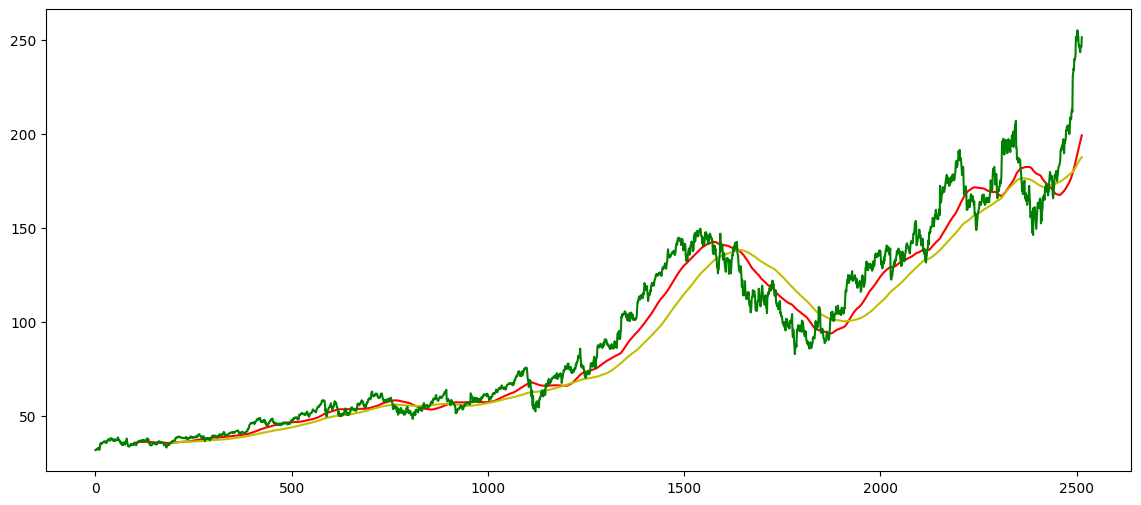

In [12]:
ma_100_days=data.Close.rolling(100).mean()
plt.figure(figsize=(14,6))
plt.plot(ma_100_days,'r')
ma_200_days=data.Close.rolling(200).mean()
plt.plot(ma_200_days,'y')
plt.plot(data.Close,'g')
plt.show()

In [13]:
data.dropna(inplace=True)
data_train=pd.DataFrame(data.Close[0:int(len(data)*0.80)])
data_test=pd.DataFrame(data.Close[int(len(data)*0.80):len(data)])

In [14]:
data_train.shape[0],data_test.shape[0]

(2011, 503)

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
data_train_scale=scaler.fit_transform(data_train)


In [16]:
x=[]
y=[]
for i in range(100,data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [17]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Input

x, y = np.array(x), np.array(y)

model = Sequential()
# Use Input layer to define input shape
model.add(Input(shape=(x.shape[1], 1)))

model.add(LSTM(units=50, activation='relu', return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

In [18]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x,y,epochs=50,batch_size=32,verbose=1)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 202ms/step - loss: 0.0511
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - loss: 0.0103
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - loss: 0.0084
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 258ms/step - loss: 0.0070
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - loss: 0.0067
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 205ms/step - loss: 0.0075
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step - loss: 0.0059
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 201ms/step - loss: 0.0059
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 217ms/step - loss: 0.0059
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 207ms/step - loss: 0.0059
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 202ms/step - loss: 0.0055
Epoch 12/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step - loss: 0.0056
Epoch 13/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - loss: 0.0057
Epoch 14/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 192ms/step - loss: 0.0047
Epoch 15/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [24]:
pas_100_days=data_train.tail(100)
data_test=pd.concat((pas_100_days,data_test),ignore_index=True)
data_test

Ticker,GOOG
0,116.105461
1,117.118530
2,116.165047
3,119.273781
4,120.654335
...,...
698,243.550003
699,245.539993
700,246.429993
701,246.449997


In [30]:
data_test_scale=scaler.fit_transform(data_test)
x=[]
y=[]
for i in range(100,data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x,y=np.array(x),np.array(y)
y_predict=model.predict(x)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step


In [29]:
y_predict

array([[0.08037749],
       [0.08034268],
       [0.08037303],
       ...,
       [0.84847325],
       [0.8417916 ],
       [0.837832  ]], shape=(1911, 1), dtype=float32)

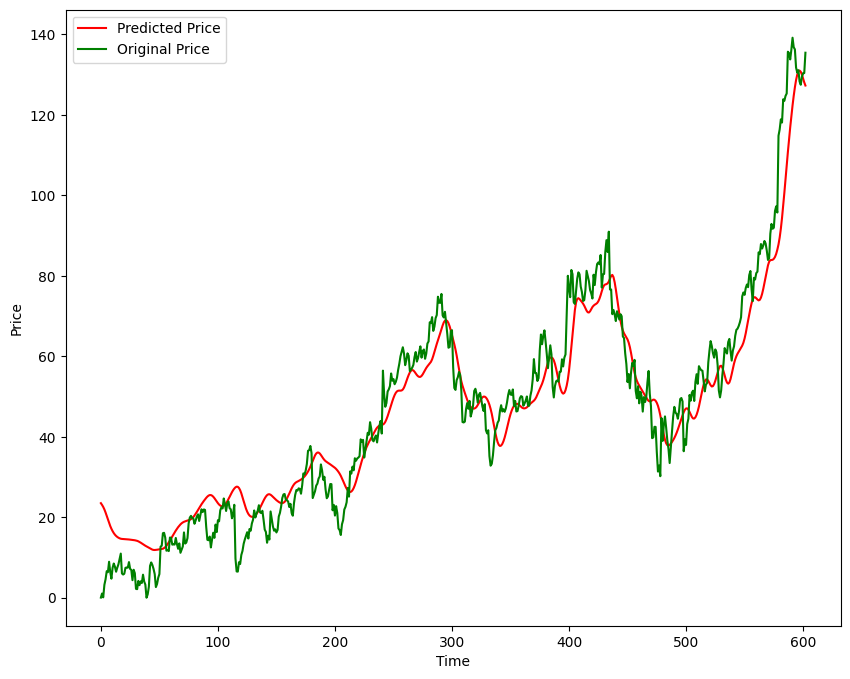

In [34]:
scale=1/scaler.scale_
y_predict=y_predict*scale
y=y*scale
plt.figure(figsize=(10,8))
plt.plot(y_predict,'r',label='Predicted Price')
plt.plot(y,'g',label='Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [35]:
model.save('Stock Prediction using Model.keras')